## <font color='purple'>Required Package Imports</font>

### Data Manipulation and Analysis
```python
import pandas as pd
import numpy as np
```

- **pandas (`pd`)**: Primary library for data manipulation and analysis
  - Provides DataFrames and Series for structured data handling
  - Essential for reading, cleaning, and transforming datasets

- **numpy (`np`)**: Fundamental package for scientific computing
  - Enables efficient numerical operations on arrays

### Data Visualization
```python
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
```

- **matplotlib.pyplot (`plt`)**: Core plotting library for creating static visualizations

- **seaborn (`sns`)**: Statistical data visualization library built on matplotlib

- **`%matplotlib inline`**: Jupyter magic command
  - Displays plots directly in notebook cells
  - Eliminates need to call `plt.show()` explicitly

### Machine Learning
```python
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
```

- **LinearRegression**: Implements ordinary least squares linear regression

- **r2_score**: Coefficient of determination metric (model evaluation)

In [64]:
#Import Required Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
%matplotlib inline 

## <font color='purple'> Data Collection (Data Science Lifecycle Element)</font>
### Data Source
The original dataset source is located [here:](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv) 

The original dataset was simplified and cleaned using this cleaning notebook [Data Cleaning Notebook](DataClean.ipynb). The resulting dataset can be found [here:](filter_automobile_data.csv)  An abbreviated data dictionary of the original dataset follows:
- **symboling** (int64)
- **normalized-losses** (int64)
- **make** (object)
- **aspiration** (object)
- **num-of-doors** (object)
- **body-style** (object)
- **drive-wheels** (object)
- **engine-location** (object)
- **wheel-base** (float64)
- **length** (float64)
- **width** (float64)
- **height** (float64)
- **curb-weight** (int64)
- **engine-type** (object)
- **num-of-cylinders** (object)
- **engine-size** (int64)
- **fuel-system** (object)
- **bore** (float64)
- **stroke** (float64)
- **compression-ratio** (float64)
- **horsepower** (float64)
- **peak-rpm** (float64)
- **city-mpg** (int64)
- **highway-mpg** (int64)
- **price** (float64)
- **city-L/100km** (float64)
- **horsepower-binned** (object)
- **diesel** (int64)
- **gas** (int64)


### Basic Data Import
⚠️ Note: This is a simplified, non-robust approach to reading data. In production environments, you should implement proper error handling, data validation, and consider additional parameters for the read_csv() function.
```python
path = 'filtered_automobile_data.csv'
df = pd.read_csv(path)
df.head()

In [189]:
path = 'filtered_automobile_data.csv'
df = pd.read_csv(path)
df.head()

,cylinders,engine-size,highway-mpg,price
0,4,130,27,13495.0
1,4,130,27,16500.0
2,6,152,26,16500.0
3,4,109,30,13950.0
4,5,136,22,17450.0


## <font color='purple'>Exploratory Data Analysis</font>
### Basic statistics and correlation analysis
#### .corr()
The corr() method calculates the Pearson correlation coefficients between all numerical variables.
- **Range**: Correlation values range from -1 to +1
- **Positive correlation (+1)**: Variables increase together
- **Negative correlation (-1)**: As one variable increases, the other decreases
- **No correlation (0)**: Variables are not linearly related
- **Strong correlation**: |r| > 0.7
- **Moderate correlation**: 0.3 < |r| < 0.7
- **Weak correlation**: |r| < 0.3

In [143]:
df.corr()

,cylinders,engine-size,highway-mpg,price
cylinders,1.000000,0.847639,-0.473746,0.708645
engine-size,0.847639,1.000000,-0.679571,0.872335
highway-mpg,-0.473746,-0.679571,1.000000,-0.704692
price,0.708645,0.872335,-0.704692,1.000000


#### describe()
The .describe() method provides comprehensive statistical summaries for all numerical columns in the dataset.  This gives a quick overview of the data distribution, central tendencies, and helps identify potential outliers or data quality issues.

In [19]:
df.describe()

,cylinders,engine-size,highway-mpg,price
count,201.000000,201.000000,201.000000,201.000000
mean,4.363184,126.875622,30.686567,13207.129353
std,1.059452,41.546834,6.815150,7947.066342
min,2.000000,61.000000,16.000000,5118.000000
25%,4.000000,98.000000,25.000000,7775.000000
50%,4.000000,120.000000,30.000000,10295.000000
75%,4.000000,141.000000,34.000000,16500.000000
max,12.000000,326.000000,54.000000,45400.000000


### Exploratory Data Analysis with Visualization
This code creates a scatter plot with regression line to visualize the relationship between highway fuel efficiency (mpg) and vehicle price. The sns.regplot() function automatically fits a linear regression line through the data points, helping identify if there's a linear relationship between these variables. The plt.ylim(0,) sets the y-axis to start at 0 for better visual interpretation of the price range.  The hollow area around the regression line in sns.regplot() is called a confidence interval (specifically, the 95% confidence interval by default).

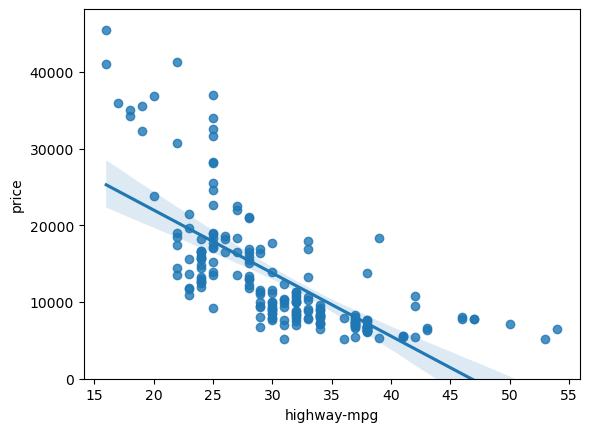

In [36]:
# Engine size as potential predictor variable of price
sns.regplot(x="highway-mpg", y="price", data=df)
plt.ylim(0,)
plt.show()

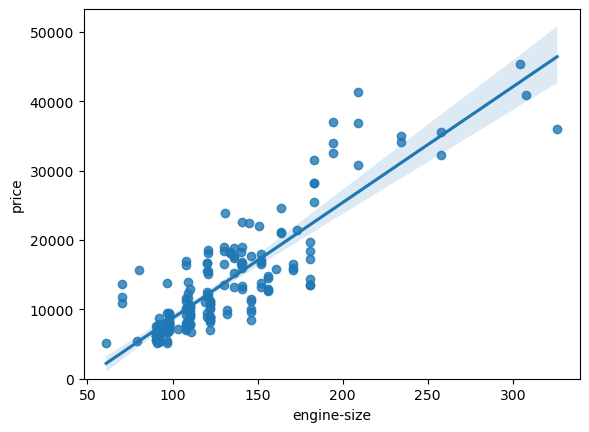

In [193]:
# Engine size as potential predictor variable of price
sns.regplot(x="engine-size", y="price", data=df)
plt.ylim(0,)
plt.show()

## <font color='purple'>Modeling the data (Data Science Lifecycle)</font>
### Linear Regression Model Setup and Training

- **`lm = LinearRegression()`** - Creates a linear regression model object from scikit-learn
- **`X = df[['engine-size']]`** - Defines the independent variable (predictor) as engine size, formatted as a DataFrame
- **`Y = df['price']`** - Defines the dependent variable (target) as price, formatted as a Series
- **`lm.fit(X,Y)`** - Trains the model by finding the best-fit line through the data points
- **`Yhat=lm.predict(X)`** - Generates predicted price values using the trained model on the engine size data
- **`predicted = Yhat[0:5]`** - Creates an array of 5 predictions
- **`predicted** - Outputs the array to consol

In [172]:
lm = LinearRegression()
X = df[['engine-size']]
Y = df['price']
lm.fit(X,Y)
Yhat=lm.predict(X)
predicted = Yhat[0:5]
predicted


array([13728.4631336 , 13728.4631336 , 17399.38347881, 10224.40280408,
       14729.62322775])

## <font color='purple'>Model Evaluation</font>
The code below takes the 5 predicted values from about and displays them in a bar chart with the actual dataset values.  This is a simplified visualization that can be used to evaluate your model.

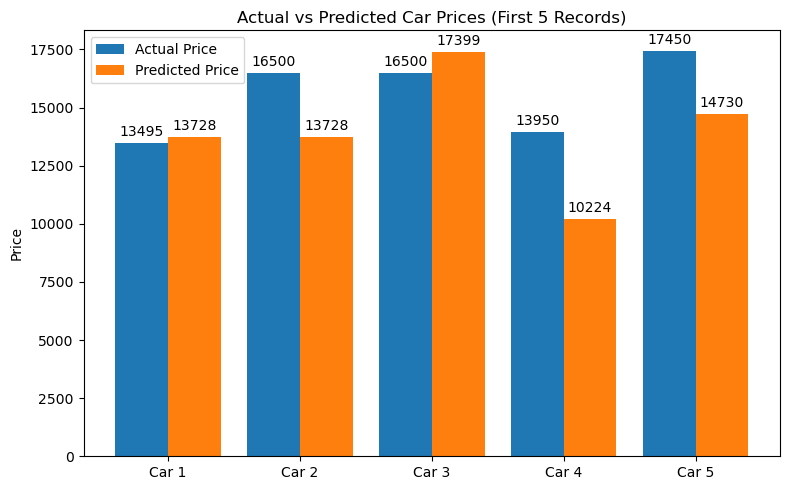

In [195]:
actual = Y.iloc[0:5].values
  
# Bar chart
labels = [f'Car {i+1}' for i in range(5)]
x = range(5)
plt.figure(figsize=(8, 5))

# Create the bars
bars1 = plt.bar(x, actual, width=0.4, label='Actual Price', align='center')
bars2 = plt.bar([i + 0.4 for i in x], predicted, width=0.4, label='Predicted Price', align='center')

# Add labels on top of bars
for i, bar in enumerate(bars1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(actual), 
             f'{actual[i]:.0f}', ha='center', va='bottom')

for i, bar in enumerate(bars2):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01*max(predicted), 
             f'{predicted[i]:.0f}', ha='center', va='bottom')

plt.xticks([i + 0.2 for i in x], labels)
plt.ylabel('Price')
plt.title('Actual vs Predicted Car Prices (First 5 Records)')
plt.legend()
plt.tight_layout()
plt.show()

### .score()

**`lm.score(X, Y)`** - Calculates the **R-squared (coefficient of determination)** for the linear regression model.

### What R-squared Represents:
- **Range**: 0 to 1 (0% to 100%)
- **Meaning**: Percentage of variance in the target variable (price) explained by the predictor variable (engine-size)
- **Interpretation**:
  - **0.0**: Model explains none of the variance (no predictive power)
  - **0.5**: Model explains 50% of the variance
  - **1.0**: Model explains all the variance (perfect fit)

In [164]:
lm.score(X, Y)

0.7609686443622008

**R² = 0.761 (76.1%)**

### What This Means (Generated by Claude Sonnet 4 7/2025):
- **Strong relationship**: Engine size explains **76.1%** of the variation in car prices
- **Good predictive power**: This is considered a strong linear relationship in most contexts
- **Remaining variance**: **23.9%** of price variation is due to other factors not captured by engine size alone

### Practical Interpretation:
- **Reliable predictor**: Engine size is a strong indicator of car price
- **Room for improvement**: Nearly 24% of price variation comes from other variables (brand, year, features, etc.)